In [1]:
from utils import (
    load_session_dumps,
    build_session_summary,
    preprocess_dumps,
    flag_outlier_dumps,
    vlsr_correction,
    build_overlap_grid,
    build_lsr_pairs,
    flag_outlier_pairs,
    combine_viable_pairs,
    assemble_W_R_arrays,
)
from plotters import (
    plot_survey_mollweide,
    plot_survey_mollweide_gridded,
)
from ugradiolab import plotting
from ugradiolab.plotting import SS_MICRO, SS_FINE

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# --- Hardware / signal-processing constants ---
SAMPLE_RATE_HZ = 3.2e6
NFFT = 1024
F1_MHZ = 1419.86
F2_MHZ = 1421.14
HPBW_DEG = 3.4
# NBLOCKS * NSAMPLES / fs (post-rewrite main pipeline)
INT_TIME_S = 1025 * 16384 / SAMPLE_RATE_HZ  # ~5.25 s

# --- RFI channel flagger (applied to both pols) ---
RFI_WINDOW = 15
RFI_SIGMA = 10.0
RFI_CHEB_DEGREE = 3
RFI_SAMPLE_FRAC = 0.7
RFI_EXTREMA_ORDER = 2

# --- Outlier dump filter ---
SHAPE_DEV_THRESH = 0.05
SHAPE_FRAC_THRESH = 0.05
SHAPE_MIN_GROUP_SIZE = 3
# Pols to shape-check: ('corr00',) pol 0 only, ('corr11',) pol 1 only,
# ('corr00', 'corr11') both.
OUTLIER_POLS = ('corr00', 'corr11')

# --- Frequency switching ---
EDGE_TRIM_MHZ = 0.256

# --- Cross-session pair filter (on dimensionless R) ---
# Filter operates on per-pol sum (R_lsr_pol0 + R_lsr_pol1) -- pols are
# propagated separately for calibration but summed here for QA stats.
PAIR_NSIGMA = 5.0
PAIR_FRAC_THRESH = 0.15
MIN_VIABLE_PAIRS = 3

# --- Paths / display ---
DATA_DIRS = [Path('data/main'), Path('data/nps')]
STATE_PATH = Path('artifacts/scan_load_state.pkl')
MOLL_CENTER_L = 120.0

get_ipython().run_line_magic('matplotlib', 'inline')

/home/ikaros/projects/ay-121/.venv/lib/python3.12/site-packages/rtlsdr/__init__.py:19: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


## 1. Load raw dumps (science pointings)

### Science motivation

Neutral atomic hydrogen (HI) is the dominant constituent of the diffuse
interstellar medium. Its ground-state hyperfine transition at
$\nu_{\mathrm{HI}} = 1420.405\,751\,768$ MHz (the 21 cm line) is
optically thin along almost every Galactic sightline, so the brightness
temperature $T_B(v)$ that we measure is directly proportional to the HI
column density per unit velocity,

$$ \frac{dN_{\mathrm{HI}}}{dv}\;=\;1.823\times 10^{18}\;T_B(v)\quad
   [\mathrm{cm^{-2}\,(km\,s^{-1})^{-1}}], $$

and the velocity-integrated brightness $W = \int T_B(v)\,dv$ in K km
s$^{-1}$ gives the total column $N_{\mathrm{HI}} = 1.823\times
10^{18}\,W$ in cm$^{-2}$ (Lab manual Sec. 11.1, eqs. (1)-(2)). The
Doppler-shifted line profile $T_B(\ell, b, v_{\mathrm{LSR}})$ encodes
the line-of-sight kinematics of HI in the Galaxy and traces spiral
structure, expanding supershells, and infalling high-velocity clouds.
Our 4.5 m Leuschner dish has half-power beamwidth
$\theta_{\mathrm{HPBW}} = 3.4^\circ$, so each pointing averages $T_B$
over a beam solid angle $\Omega_b \approx 1.13\,\theta_{\mathrm{HPBW}}^2
\approx 13$ deg$^2$; the survey samples those pointings on the Nyquist
grid $\Delta\ell = 2^\circ/\cos b,\;\Delta b = 2^\circ$ (Lab manual
Sec. 5: two samples per HPBW, foreshortening-corrected in $\ell$).

### What a "dump" is

The raw observable is the band-averaged correlator power spectrum
returned by each RTL-SDR. Each `.npz` file holds one such dump: two
1024-channel float64 spectra (`corr00` for pol 0, `corr11` for pol 1)
plus scalar metadata (LO frequency, noise-diode state, UNIX time, alt /
az, RA / dec). With NSAMPLES $= 16384$ and NBLOCKS $= 1025$ at sample
rate $f_s = 3.2$ MHz, each dump integrates
$\tau_{\mathrm{dump}} = N_{\mathrm{samp}} N_{\mathrm{block}} / f_s
\approx 5.25$ s and is the smallest unit that propagates through the
pipeline. The radiometer equation
$\Delta T / T_{\mathrm{sys}} = 1/\sqrt{\Delta\nu\,\tau}$
(Heiles, *Calibrating the Intensity and Shape of Spectral Lines*,
Sec. 2 eq. (1)) with $\Delta\nu \approx f_s / N_{\mathrm{FFT}} = 3.1$
kHz per channel gives a per-channel, per-dump fractional noise of
$\sim 8\times 10^{-3}$ -- the floor that drives our $\geq 8$
obs-dump / cell schedule.

### Loader behaviour

`load_session_dumps` walks `data/{main,nps}/session_*/{obs,cal}_*/` and
keeps science cells only; recal-drift pointings are matched by
filename prefix and routed to `main_scan_calibration.ipynb` for the
noise-diode $T_{\mathrm{cal}}(t)$ solve. ICRS (RA, Dec) is converted to
galactic $(\ell, b)$ in a single vectorised `astropy.SkyCoord` call and
rounded to the survey grid (two decimals on $\ell$, integer on $b$).
The result is cached on disk via `joblib`, keyed by the tuple of
(path, mtime) over every dump file, so a re-run is free unless the
on-disk data has changed.

In [2]:
records = load_session_dumps(DATA_DIRS)
sessions = sorted({r['session'] for r in records})

display(build_session_summary(records, INT_TIME_S))

n_sci = sum(1 for r in records if not r['noise_on'])
n_cal = sum(1 for r in records if r['noise_on'])
lo_unique = sorted({r['lo_mhz'] for r in records if not r['noise_on']})
print(f'Science: {len(records)} dumps ({n_sci} obs, {n_cal} cal), '
      f'{len(sessions)} sessions, LO: {lo_unique}')


,Session,UTC Start,UTC End,Wall (min),Obs. Cells,Dumps,Duty %
0,main/session_001,2026-05-14 01:56,2026-05-14 02:40,44.0,24,288,57.3
1,nps/session_001,2026-05-14 02:59,2026-05-14 06:25,206.6,110,1320,55.9
2,main/session_002,2026-05-14 07:34,2026-05-14 09:35,121.0,63,756,54.7
3,main/session_003,2026-05-14 09:41,2026-05-14 12:14,153.3,82,984,56.1
4,main/session_004,2026-05-14 12:32,2026-05-14 15:16,163.3,83,996,53.4
...,...,...,...,...,...,...,...
65,main/session_119,2026-05-19 15:28,2026-05-19 15:34,5.5,4,48,76.6
66,main/session_120,2026-05-19 15:38,2026-05-19 15:44,5.4,4,48,77.2
67,main/session_121,2026-05-19 15:48,2026-05-19 16:58,69.4,40,480,60.5
68,main/session_122,2026-05-19 22:25,2026-05-19 22:40,15.2,10,120,68.9


Science: 33480 dumps (22320 obs, 11160 cal), 70 sessions, LO: [1419.86, 1421.14]


## 2. fftshift + RFI flagging + outlier dump filter

### fftshift and per-pol propagation

`np.fft.fftshift` re-orders the SDR's baseband channels so that index 0
holds the most negative IF frequency and index $N_{\mathrm{FFT}} - 1$
holds the most positive, giving a monotonically increasing baseband
axis $f_{\mathrm{bb}}\in[-f_s/2,\,f_s/2)$. Pol 0 (`corr00`) and pol 1
(`corr11`) are flagged and propagated independently because the noise
diode couples differently into each: $T_{\mathrm{cal}}^{(0)} = 58$ K vs
$T_{\mathrm{cal}}^{(1)} = 79$ K (Lab manual Sec. 4.3). Summing the two
pols into a Stokes-I product before the per-pol calibration would
discard that distinction; the sum is therefore deferred to the plotting
stage (Sections 5, 6, 6b), after calibration.

### RFI: sliding Chebyshev pseudo-continuum + MAD clip

A narrowband interferer adds a localised power spike on top of the
smooth instrumental bandpass $G_j$ (`utils/rfi.py`). To locate spikes
without biasing on the spikes themselves, for every channel $j$ we fit
a degree-$d$ Chebyshev polynomial $P(x;\mathbf{c})$ to the window
$[j-w/2,\,j+w/2]$ after (i) excluding local extrema -- an RFI peak is
by definition a local maximum -- via `scipy.signal.argrelextrema` with
`order` $= k$, and (ii) drawing a random subsample (fraction
$\alpha$) of the surviving points to break any residual structure
correlation. The fit value at the window centre gives the
pseudo-continuum estimate
$\hat C_j = P(w/2;\hat{\mathbf{c}})$. Let $r_j = s_j - \hat C_j$ be the
residual; its robust scale is

$$ \hat\sigma\;=\;\frac{\mathrm{MAD}(r)}{0.6745},\qquad
   \mathrm{MAD}(r)\;=\;\mathrm{median}_j\,|r_j|, $$

where $0.6745 = \Phi^{-1}(3/4)$ makes $\hat\sigma$ a consistent
estimator of the Gaussian standard deviation in the absence of
outliers. Channels with $|r_j| > n_\sigma\,\hat\sigma$ are set to NaN
in place (`flag_rfi_channels`, here $n_\sigma = 10$, $w = 15$, $d = 3$,
$\alpha = 0.7$, extrema order 2). The window is reflect-padded at both
edges so every channel sees a full-width window.

This *pseudo-continuum* is used only to localise outlier channels: the
actual bandpass $G_j$ is cancelled later by frequency switching
(Section 3), so we never need to fit it analytically the way single-LO
observations do (cf. Heiles, *Calibrating the Intensity and Shape of
Spectral Lines*, Sec. 5: polynomial baseline subtraction is necessary
only when $G_j$ has not been removed by switching).

### Shape-based outlier dump filter

Cells are observed in coherent ABBA dump groups within a single
session visit. Group every science dump by the tuple $(\mathrm{session},\,
\ell,\,b,\,\nu_{\mathrm{LO}})$; within each group the bandpass, beam,
atmosphere and HI emission should be identical up to thermal noise.
For each pol independently we compute the per-group median spectrum
$m_j = \mathrm{median}_i\,s_j^{(i)}$, form the per-dump ratio
$\rho_j^{(i)} = s_j^{(i)} / m_j$, and count the deviant channels

$$ f^{(i)}\;=\;\frac{\#\{j\,:\,|\rho_j^{(i)} - 1| > \tau_{\mathrm{dev}}\}}
                    {\#\{j\,:\,\rho_j^{(i)}\;\mathrm{finite}\}}. $$

A dump is dropped if $f^{(i)} > \tau_{\mathrm{frac}}$ on any
flag-eligible pol with a usable group median. The defaults
($\tau_{\mathrm{dev}} = 0.05,\,\tau_{\mathrm{frac}} = 0.05$) catch
dumps with impulsive interference or USB hiccups (which manifest as a
broadband multiplicative offset) but leave normal dump-to-dump scatter
untouched. Groups smaller than `min_group_size = 3` skip the test
because the median itself becomes unreliable.

In [3]:
n_rfi = preprocess_dumps(
    records,
    rfi_window=RFI_WINDOW,
    rfi_sigma=RFI_SIGMA,
    rfi_degree=RFI_CHEB_DEGREE,
    rfi_sample_frac=RFI_SAMPLE_FRAC,
    rfi_extrema_order=RFI_EXTREMA_ORDER,
)
print(f'Science: RFI flagged {n_rfi} channel samples '
      f'across {len(records)} dumps (both pols)')

sci_out = flag_outlier_dumps(
    records,
    dev_thresh=SHAPE_DEV_THRESH,
    frac_thresh=SHAPE_FRAC_THRESH,
    min_group_size=SHAPE_MIN_GROUP_SIZE,
    pols=OUTLIER_POLS,
)
print(f'Outlier dump filter: removed {len(sci_out)} science '
      f'(>{SHAPE_FRAC_THRESH:.0%} channels deviate >{SHAPE_DEV_THRESH:.0%} from group median, '
      f'pols={OUTLIER_POLS})')
print(f'Remaining: {len(records)} science dumps')

Science: RFI flagged 235238 channel samples across 33480 dumps (both pols)
Outlier dump filter: removed 0 science (>5% channels deviate >5% from group median, pols=('corr00', 'corr11'))
Remaining: 33480 science dumps


## 3. Frequency switching: from raw power to the dimensionless ratio $R$

### Receiver model

Following Heiles, *Calibrating the Intensity and Shape of Spectral
Lines* (Secs. 2-3), the measured power in baseband channel $j$ at LO
frequency $\nu_{\mathrm{LO}}$ with the noise diode off is

$$ P_j(\nu_{\mathrm{LO}})\;=\;G_j\,\bigl[\,T_{\mathrm{sys}}
   + T_{B}\!\left(\nu_{\mathrm{LO}} + f_{\mathrm{bb},j}\right)\,\bigr], $$

where $G_j$ is the per-channel system gain (dominated by the IF
bandpass), $T_{\mathrm{sys}} = T_{\mathrm{rcvr}} + T_{\mathrm{ant,cont}}$
is the frequency-independent continuum system temperature, and
$T_{B}(\nu)$ is the sky brightness expressed as a function of *sky*
frequency. Crucially, $G_j$ depends only on the IF / channel index
$j$, not on the LO, because the IF chain sits downstream of the first
mixer (Heiles, Sec. 2.2.1).

### The freq-switching ratio

Taking two dumps at LOs $\nu_1$ and $\nu_2 = \nu_1 + \Delta\nu_{\mathrm{LO}}$
through the same channel $j$ and forming the dimensionless ratio

$$ R_j\;\equiv\;\frac{P_j(\nu_1) - P_j(\nu_2)}{P_j(\nu_2)}
   \;=\;\frac{T_B(\nu_1 + f_{\mathrm{bb},j})
            - T_B(\nu_2 + f_{\mathrm{bb},j})}
            {T_{\mathrm{sys}}
            + T_B(\nu_2 + f_{\mathrm{bb},j})}, $$

cancels $G_j$ exactly and removes the constant $T_{\mathrm{sys}}$ from
the numerator. In the optically thin, weak-line regime
$T_B \ll T_{\mathrm{sys}}$ (typical $T_B^{\mathrm{HI}} \lesssim 100$ K,
$T_{\mathrm{sys}} \approx 200$-300 K at $\nu_{\mathrm{HI}}$), the
denominator simplifies and

$$ R_j\;\approx\;\frac{T_B(\nu_1 + f_{\mathrm{bb},j})
                     - T_B(\nu_2 + f_{\mathrm{bb},j})}
                      {T_{\mathrm{sys}}}, $$

i.e. $R$ is the line-to-system-temperature ratio with the
instrumental bandpass divided out. Restoring the absolute intensity
scale later requires only the *scalar* $T_{\mathrm{sys}}$ from the
noise-diode calibration: $T_B \approx R\cdot T_{\mathrm{sys}}$. This is
Heiles's "cool method" (eq. (\ref{cool2}) in `cal_intensity.tex`): the
*shape* of the line comes from the low-noise ratio of two power
spectra, and the *vertical scale* comes from the noise diode (Section
7 caches the scalars; `main_scan_qa.ipynb` applies them).

### Geometry: the sky-frequency overlap

The SDR delivers a baseband window $f_{\mathrm{bb}}\in[-f_s/2,\,f_s/2)$
($f_s = 3.2$ MHz), so each LO observes the sky band
$\mathcal{B}_k = [\nu_k - f_s/2,\,\nu_k + f_s/2)$. The two LO bands
overlap in $\mathcal{B}_1\cap\mathcal{B}_2$, trimmed by
`EDGE_TRIM_MHZ` ($= 0.256$ MHz) on each side to avoid the SDR's
analogue rolloff. The kept channels (one boolean mask `overlap_mask`
over the 1024 baseband indices) define the sky-frequency overlap that
anchors the velocity grid through the Doppler relation

$$ v_{\mathrm{topo}}(\nu)\;=\;c\,\left(1 - \frac{\nu}{\nu_{\mathrm{HI}}}\right)
   \quad [\mathrm{km\,s^{-1}}], $$

with the convention that positive $v$ is recession (line at lower
frequency than rest); equivalently $v = -c\,\Delta\nu/\nu_{\mathrm{HI}}$
relative to the line centre (Lab manual Sec. 11.1). For
$\nu_1 = 1419.86$ MHz, $\nu_2 = 1421.14$ MHz with 256 kHz edge trim,
the surviving overlap is $[1419.80,\,1421.20]$ MHz, covering roughly
$v_{\mathrm{topo}}\in[-168,\,128]$ km s$^{-1}$ -- ample for Galactic
HI ($|v_{\mathrm{LSR}}|\lesssim 250$ km s$^{-1}$). The velocity
resolution per channel is
$\Delta v = c\,(f_s/N_{\mathrm{FFT}}) / \nu_{\mathrm{HI}}
\approx 0.66$ km s$^{-1}$.

### DC and the freq-switching "ghost"

Channel $N_{\mathrm{FFT}}/2 = 512$ (DC after `fftshift`) carries a
deterministic spike from the SDR's I/Q DC offset and must be masked
before any integration (handled in Section 7's `INT_MASK`). Note also
that the channel-wise difference $R_j$ produces *two* copies of the
line within the overlap: a positive copy at the channel where LO1
places the rest frequency
($f_{\mathrm{bb}} \approx \nu_{\mathrm{HI}} - \nu_1 = +0.55$ MHz) and
a negative "mirror" copy at the channel where LO2 places it
($f_{\mathrm{bb}} \approx \nu_{\mathrm{HI}} - \nu_2 = -0.74$ MHz). The
two are separated in $v_{\mathrm{topo}}$ by
$c\,\Delta\nu_{\mathrm{LO}}/\nu_{\mathrm{HI}} \approx 270$ km s$^{-1}$,
so for our LO pair the mirror falls outside the overlap velocity
window and is naturally excluded from $W_R$.

In [4]:
grid = build_overlap_grid(
    F1_MHZ, F2_MHZ, SAMPLE_RATE_HZ, NFFT,
    edge_trim_mhz=EDGE_TRIM_MHZ,
)
overlap_mask = grid['overlap_mask']
v_overlap = grid['v_overlap']
dv_kms = grid['dv_kms']

print(f'LO pair: ({F1_MHZ}, {F2_MHZ}) MHz')
print(f"Overlap: [{grid['f_overlap_lo']:.2f}, {grid['f_overlap_hi']:.2f}] MHz")
print(f'Velocity (topo): [{v_overlap[-1]:.0f}, {v_overlap[0]:.0f}] km/s')
print(f'dv = {dv_kms:.3f} km/s per channel')


LO pair: (1419.86, 1421.14) MHz
Overlap: [1419.80, 1421.20] MHz
Velocity (topo): [-168, 128] km/s
dv = 0.660 km/s per channel


## 4. LSR correction, cross-session pair filter, combine

No temperature calibration is applied yet. The spectra propagated here
are the dimensionless frequency-switched ratios $R(v_{\mathrm{LSR}})$
for each pol independently (`R_pol0` from `corr00`, `R_pol1` from
`corr11`).

### Topocentric -> Local Standard of Rest

The frequency-to-velocity map of Section 3 gives a *topocentric*
velocity: the line frequency in the rest frame of the SDR sitting at
Leuschner ($\phi = +37.92^\circ$, $\lambda = -122.11^\circ$, $h = 304$
m). To compare spectra taken at different sidereal times and different
sky positions on a common axis, we shift each spectrum to the Local
Standard of Rest (LSR), the frame co-rotating with the local Galactic
disk. The total correction has two pieces (`utils/lsr.py`):

1. **Heliocentric** -- removes the Earth's orbital and diurnal motion
   relative to the Sun. For a source unit vector $\hat n_{\mathrm{src}}$
   in ICRS, the correction is the projection
   $v_{\mathrm{helio}} = -\hat n_{\mathrm{src}}\cdot
   \mathbf{v}_{\mathrm{obs}}^{\mathrm{helio}}$, where the observer
   velocity sums the Earth's barycentric orbital velocity ($\sim 30$ km
   s$^{-1}$, time-of-year dependent) and the diurnal rotation at
   Leuschner ($\le 0.34$ km s$^{-1}$). `astropy` computes this via
   `SkyCoord.radial_velocity_correction(kind='heliocentric',
   obstime=t, location=LEO_LOCATION)` at sub-m s$^{-1}$ accuracy.

2. **Kinematic LSR / solar apex** -- adds the projection of the Sun's
   peculiar motion onto the line of sight. The IAU-standard kinematic
   LSR places the Sun in motion at $V_\odot = 20$ km s$^{-1}$ toward
   $(\alpha,\,\delta) = (18^\mathrm{h},\,+30^\circ)$ in B1900, so

   $$ v_{\mathrm{apex}}(\hat n)
      \;=\;V_\odot\,\cos\theta,\qquad
      \cos\theta\;=\;\hat n\cdot\hat n_{\mathrm{apex}}, $$

   with $\hat n_{\mathrm{apex}}$ obtained by transforming the
   B1900 apex coordinates into the current ICRS.

The combined shift $v_{\mathrm{corr}} = v_{\mathrm{helio}} +
v_{\mathrm{apex}}$ satisfies $v_{\mathrm{LSR}} = v_{\mathrm{topo}} +
v_{\mathrm{corr}}$. We compute $v_{\mathrm{corr}}$ once per
`(session, gl, gb)` using the group's mean observation time and the
cell's (RA, Dec). Across our $\sim 6$-day observing window and
$\sim 250^\circ$ longitude footprint the per-cell values span tens of
km s$^{-1}$ -- much larger than the channel spacing
$\Delta v = 0.66$ km s$^{-1}$, so the correction must be applied *per
cell*, not as a single global shift. We then build one *shared* LSR
grid by offsetting `v_overlap` by the mean of the per-cell
$v_{\mathrm{corr}}$ values (this just fixes a convenient axis for
stacking and plotting), and linearly interpolate each cell's per-pair
spectrum from its own
$v_{\mathrm{topo}} + v_{\mathrm{corr}}^{\mathrm{cell}}$ axis onto that
shared grid. The interpolation is exact at the channel level; the only
loss is the sub-channel smoothing of `numpy.interp`'s linear kernel,
$\ll$ the HI line width.

### Pairing dumps and forming per-pair $R$

`build_lsr_pairs` groups obs dumps by `(session, gl, gb)`. Within each
group the LO1 and LO2 dumps are paired in arrival order (ABBA schedule,
so consecutive dumps alternate LOs); if a group has $n_1$ LO1 dumps
and $n_2$ LO2 dumps, $\min(n_1, n_2)$ pairs are formed. Each pair
yields one dimensionless $R$ spectrum per pol (Section 3), interpolated
onto the shared LSR grid via 1-D linear interpolation.

### Cross-session pair filter

A cell may be revisited across multiple sessions, giving 4-20 pairs
that should agree to within thermal noise after the frequency switch.
We use this redundancy to reject pairs that disagree with the
population. For each cell $(\ell, b)$ with at least
`MIN_VIABLE_PAIRS = 3` pairs, stack the per-pair spectra
$R^{(p)}_j$ into an $N_p \times N_j$ matrix and compute the
per-channel population median and robust scale:

$$ m_j\;=\;\mathrm{median}_p R^{(p)}_j,\qquad
   \sigma_j\;=\;1.4826\cdot\mathrm{median}_p\,|R^{(p)}_j - m_j|. $$

The factor $1.4826 = 1/0.6745$ converts MAD to a Gaussian-equivalent
standard deviation. Score every pair by its deviant-channel fraction
at threshold $n_\sigma$ (here 5),

$$ f^{(p)}\;=\;\mathrm{mean}_j\,
   \mathbf{1}\!\left[\,\left|R^{(p)}_j - m_j\right| > n_\sigma\,\sigma_j\,\right], $$

and drop pairs with $f^{(p)} > \tau_{\mathrm{pair}}$ (here 15%). The
filter is run once per pol (`R_lsr_pol0`, `R_lsr_pol1`); a pair flagged
on either pol is dropped, matching the per-pol propagation throughout
the pipeline. Cells with fewer than $3$ pairs skip the test because
the population median is not robust below that threshold.

### Combining surviving pairs

For each pol and each cell, the per-pair $R$ spectra are averaged
channel-wise with `np.nanmean`. Under i.i.d. thermal noise per pair,
the spectrum-averaged noise improves as
$\delta R \propto 1/\sqrt{N_{\mathrm{pairs}}}$ (Heiles, Sec. 4.1
"root-$N$ rule": $\sigma_{\bar x} = \sigma_x/\sqrt N$). Cells with
fewer than `MIN_VIABLE_PAIRS = 3` *surviving* pairs are still combined
(so they appear on the map) but are recorded in
`cells_insufficient_pairs` for the QA reobserve list. Downstream
calibration in `main_scan_qa.ipynb` applies pol-specific
$T_{\mathrm{cal}}^{\mathrm{pol}}(t)$ to each pol before any further
summing.

Recal pointings are handled separately by
`main_scan_calibration.ipynb`. Neighbour-based QA on the resulting
cell spectra is performed in `main_scan_qa.ipynb`, which loads
`artifacts/scan_load_state.pkl`.

In [5]:
print('Building LSR-corrected per-pair R for science cells...')
cell_pairs, obs_dumps_by_cell, v_lsr_overlap, mean_vcorr = build_lsr_pairs(
    records,
    lo1=F1_MHZ, lo2=F2_MHZ,
    overlap_mask=overlap_mask,
    v_overlap=v_overlap,
    vlsr_correction_fn=vlsr_correction,
)
print(f'Mean v_corr = {mean_vcorr:.2f} km/s -- '
      f'LSR velocity range: [{v_lsr_overlap[-1]:.0f}, {v_lsr_overlap[0]:.0f}] km/s')

n_pairs_total = sum(len(v) for v in cell_pairs.values())

# Cross-session pair filter: run per pol.  The second pass operates on
# pairs that survived the first, so a pair flagged on either pol is
# dropped.
viable_pairs_per_cell = cell_pairs
flagged_pair_records: list[dict] = []
for pol_in_key in ('R_lsr_pol0', 'R_lsr_pol1'):
    viable_pairs_per_cell, flagged_this_pol = flag_outlier_pairs(
        viable_pairs_per_cell,
        n_sigma=PAIR_NSIGMA,
        frac_thresh=PAIR_FRAC_THRESH,
        min_pairs=MIN_VIABLE_PAIRS,
        spectrum_key=pol_in_key,
    )
    flagged_pair_records.extend(flagged_this_pol)
    print(f'Pair filter ({pol_in_key}): flagged '
          f'{len(flagged_this_pol)} pairs '
          f'(NSIGMA={PAIR_NSIGMA}, frac>{PAIR_FRAC_THRESH:.0%})')
print(f'Pair filter total: {len(flagged_pair_records)}/{n_pairs_total} pairs flagged')

# Combine surviving pairs: average each pol independently into cell_combined.
cell_combined: dict = {}
cells_insufficient_pairs: list[dict] = []
for pol_in_key, pol_out_key in (
    ('R_lsr_pol0', 'R_pol0'),
    ('R_lsr_pol1', 'R_pol1'),
):
    cell_combined, cells_insufficient_pairs = combine_viable_pairs(
        viable_pairs_per_cell,
        min_pairs=MIN_VIABLE_PAIRS,
        spectrum_key=pol_in_key,
        out_key=pol_out_key,
        cell_combined=cell_combined,
    )

n_valid = sum(
    1 for v in cell_combined.values()
    if np.count_nonzero(np.isfinite(v['R_pol0']) & np.isfinite(v['R_pol1'])) >= 8
)
print(f'Combined (LSR, per-pol R): {len(cell_combined)} cells '
      f'({n_valid} with >=8 channels finite in both pols)')
print(f'Cells with <{MIN_VIABLE_PAIRS} viable pairs: {len(cells_insufficient_pairs)}')


Building LSR-corrected per-pair R for science cells...
Mean v_corr = 3.18 km/s -- LSR velocity range: [-165, 132] km/s


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:565: RuntimeWarning: All-NaN slice encountered
  median = np.nanmedian(R_stack, axis=0)
/home/ikaros/projects/ay-121/labs/04/utils/qa.py:566: RuntimeWarning: All-NaN slice encountered
  mad = np.nanmedian(np.abs(R_stack - median), axis=0) * 1.4826


Pair filter (R_lsr_pol0): flagged 0 pairs (NSIGMA=5.0, frac>15%)
Pair filter (R_lsr_pol1): flagged 0 pairs (NSIGMA=5.0, frac>15%)
Pair filter total: 0/11160 pairs flagged
Combined (LSR, per-pol R): 2733 cells (2733 with >=8 channels finite in both pols)
Cells with <3 viable pairs: 0


/home/ikaros/projects/ay-121/labs/04/utils/qa.py:639: RuntimeWarning: Mean of empty slice
  entry[out_key] = np.nanmean([p[spectrum_key] for p in pairs], axis=0)


## 5. Integrated frequency-switched ratio map $W_R(\ell, b)$

### From spectrum to scalar

A first look at the survey collapses the velocity axis to a single
scalar per cell -- the velocity-integrated dimensionless ratio

$$ W_R(\ell, b)\;=\;\int R(\ell, b, v_{\mathrm{LSR}})\,dv_{\mathrm{LSR}}
   \;\approx\;\Delta v\sum_j R_j\quad[\mathrm{km\,s^{-1}}]. $$

This is the dimensionless analogue of the calibrated column-density
integral

$$ W\;=\;\int T_B(v)\,dv\;\;[\mathrm{K\,km\,s^{-1}}],\qquad
   N_{\mathrm{HI}}\;=\;1.823\times 10^{18}\,W\;\;[\mathrm{cm^{-2}}], $$

related by the cell- and pol-dependent scalar $T_{\mathrm{sys}}$
through $T_B = R\cdot T_{\mathrm{sys}}$ (Section 3). Deferring the
calibration to QA time makes this map a useful sanity check that is
*not* contaminated by gain or $T_{\mathrm{sys}}$ drift between
sessions: variation in $W_R$ across cells reflects real changes in line
shape and amplitude, not in calibration. The calibrated $W$ and the
derived $N_{\mathrm{HI}}$ map are produced in `main_scan_qa.ipynb`
after pol-specific $T_{\mathrm{cal}}^{\mathrm{pol}}(t)$ is applied.

### Pol summing and Stokes I

The dish + receiver feeds are two nominally orthogonal linear
polarisations whose autocorrelation powers sum to Stokes I (total
intensity) for unpolarised thermal HI emission: $I = P_{xx} + P_{yy}$,
so $R_I = R_{\mathrm{pol0}} + R_{\mathrm{pol1}}$ up to a normalisation
absorbed into $T_{\mathrm{sys}}$. The sum gives a $\sqrt{2}$ SNR
improvement because the two RTL-SDRs are independent receiver chains
with uncorrelated thermal noise (Heiles, Sec. 4.2: when two
equal-noise estimators are summed, the signal doubles while the noise
grows by $\sqrt{2}$, for a net SNR gain of $\sqrt{2}$).

### Beam vs source: $T_A$ vs $T_B$

What the antenna actually delivers is the antenna temperature $T_A$,
related to the brightness $T_B$ through the beam dilution factor (Lab
manual Sec. 11.1 eq. (3), the "Fount of All Knowledge!" relation):

$$ T_A\;\approx\;T_B\,\frac{\Omega_s}{\Omega_s + \Omega_b}, $$

where $\Omega_b \sim 1.13\,\theta_{\mathrm{HPBW}}^2$ is the beam solid
angle and $\Omega_s$ the source solid angle. Two limits:

- $\Omega_s\gg\Omega_b$ (diffuse, beam-filling): $T_A\approx
  \langle T_B\rangle_{\Omega_b}$.
- $\Omega_s\ll\Omega_b$ (compact): $T_A\approx \langle T_B\rangle\,
  \Omega_s/\Omega_b$, i.e. the source is diluted by the beam-to-source
  area ratio.

Galactic-plane HI is essentially everywhere a beam-filling diffuse
emission, so for our survey $T_A\approx\langle T_B\rangle_{\Omega_b}$
and the map below can be read as a beam-averaged column density once
calibrated. For unresolved high-velocity clouds the dilution must be
folded back in by hand.

### Mollweide projection

The Mollweide projection (equal-area, sinusoidal meridians) preserves
relative integrated intensities across the sky -- a 1 deg$^2$ patch at
$b = 60^\circ$ and a 1 deg$^2$ patch on the plane occupy the same
fraction of the displayed area, so eye comparisons of $W_R$ are
unbiased by latitude (unlike a cylindrical equidistant projection
where high-$|b|$ cells appear horizontally stretched by $1/\cos b$;
Lab manual Sec. 11.2). The plot is centred on $\ell_0 = 120^\circ$ so
the surveyed footprint sits contiguously inside the visible
hemisphere, and a hatched red overlay shows the never-observable
galactic region (alt $\in [17, 83]^\circ$, az $\in [7, 348]^\circ$
from Leuschner's $+37.92^\circ$ latitude).

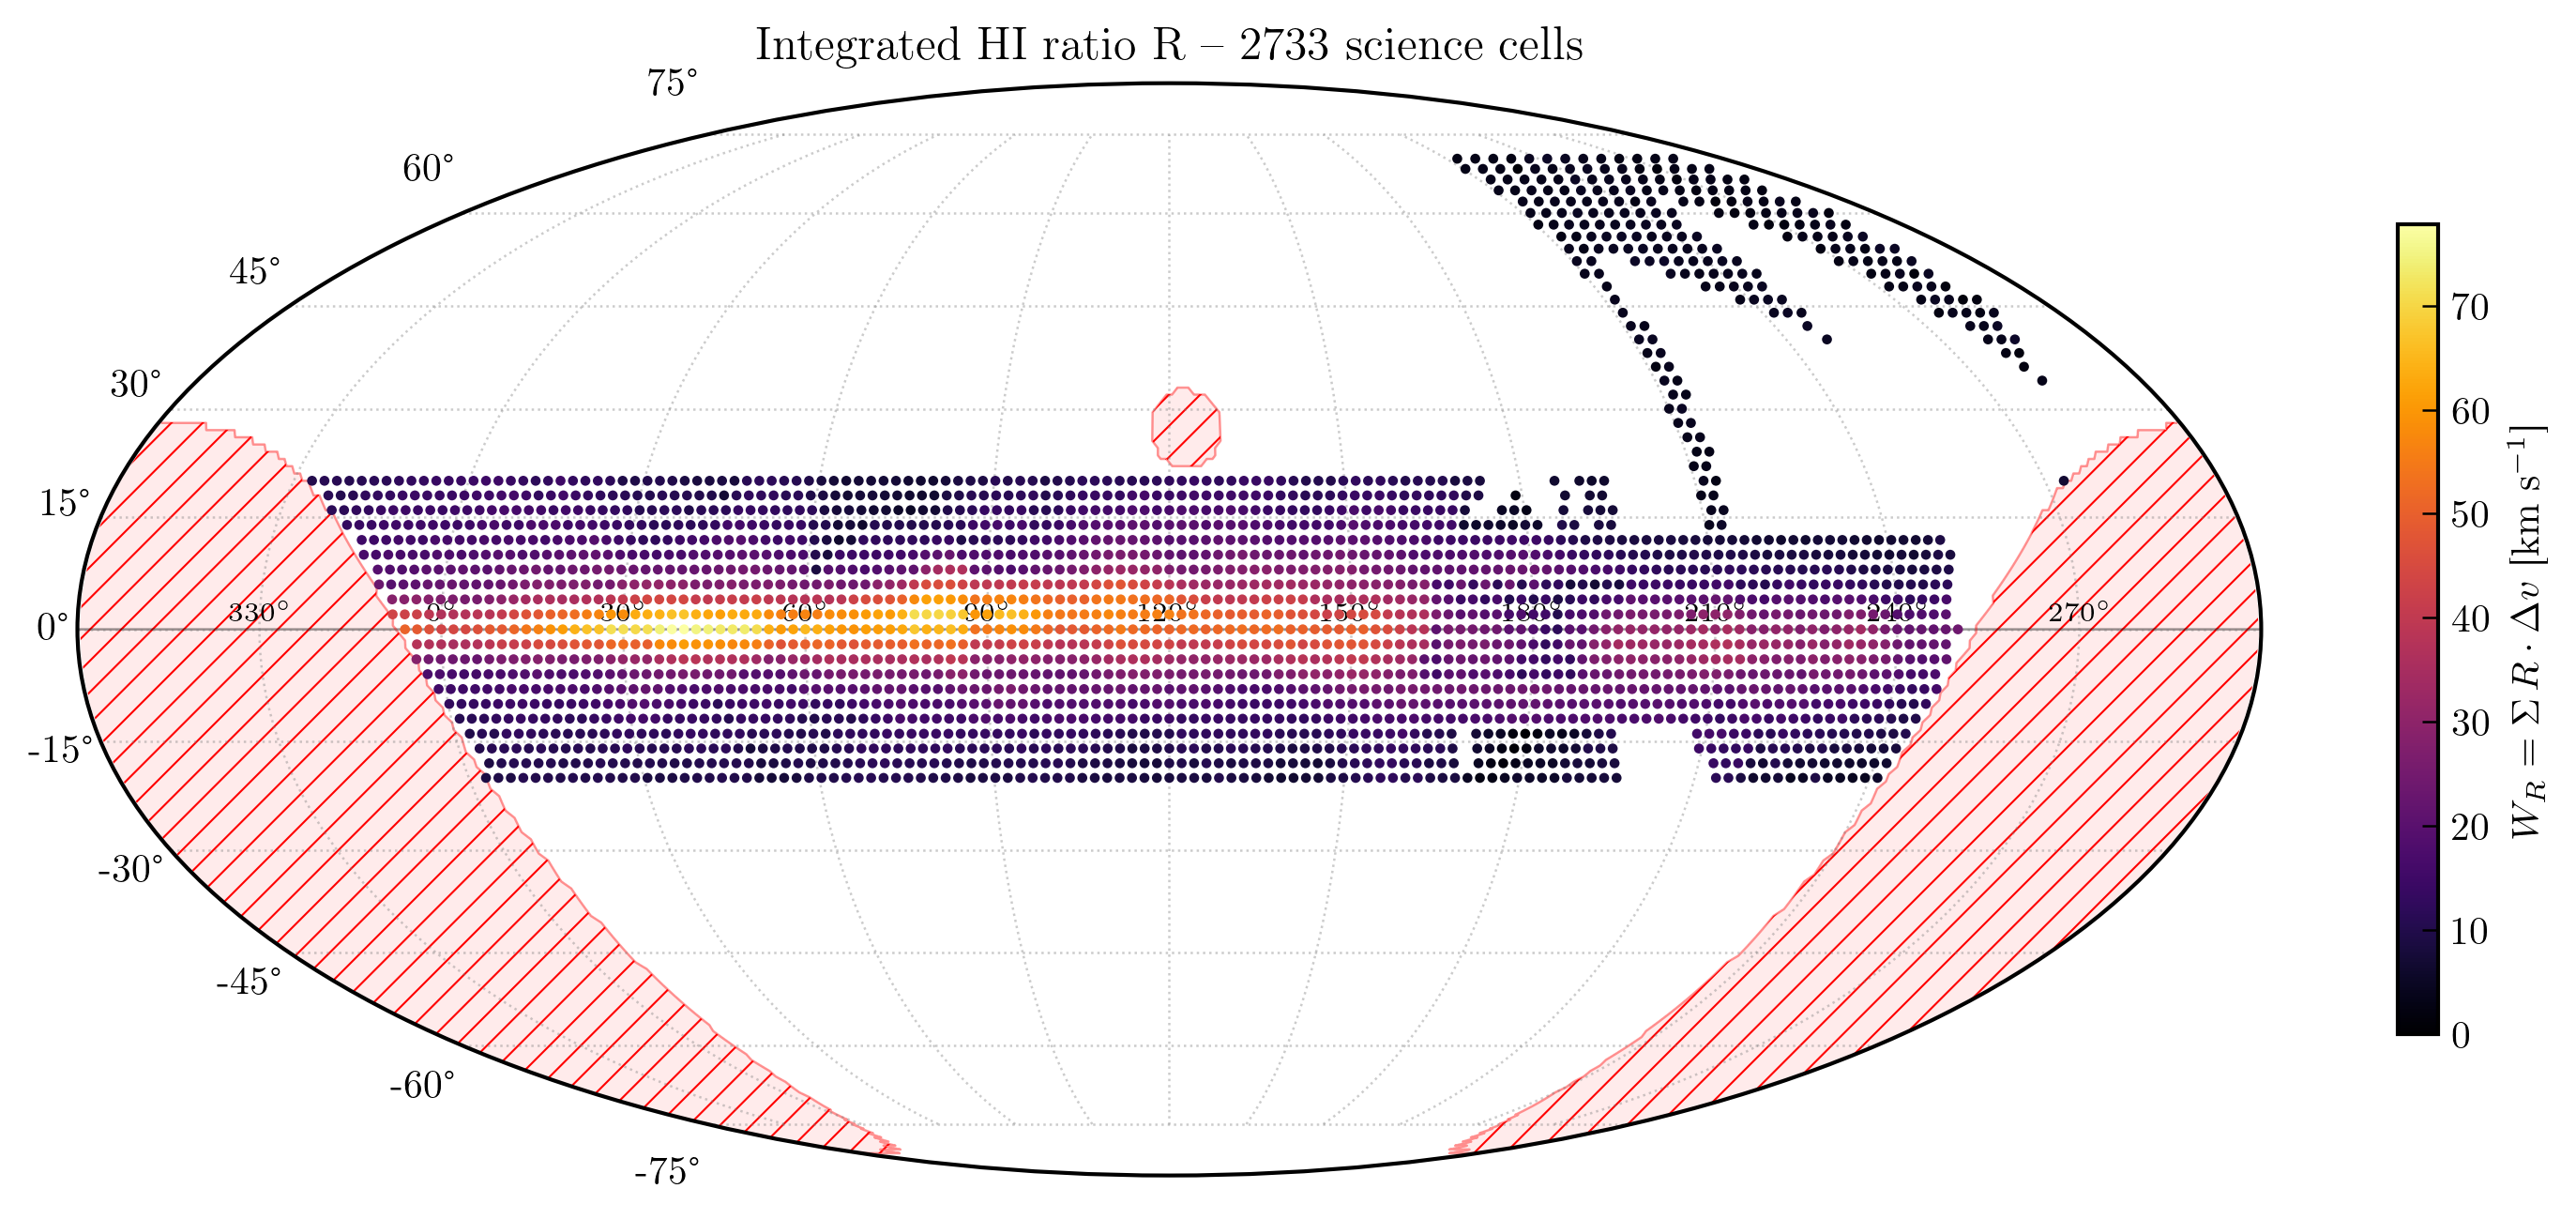

In [6]:
# Plot-stage Stokes I: sum the per-pol R means into a single 'R' key.
for entry in cell_combined.values():
    entry['R'] = entry['R_pol0'] + entry['R_pol1']

arrs = assemble_W_R_arrays(cell_combined, dv_kms, spectrum_key='R')
gl_arr, gb_arr, W_R, valid_R = arrs['gl'], arrs['gb'], arrs['W_R'], arrs['valid']

fig, ax = plot_survey_mollweide(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    marker_size=(SS_FINE + SS_MICRO) / 2,
    title=f'Integrated HI ratio R -- {arrs["n_sci"]} science cells',
)
plt.show()

## 6. Beam-weighted Mollweide map of integrated $R$

### Motivation: regridding under a Gaussian beam

The survey samples $W_R(\ell, b)$ at discrete pointings spaced
$\Delta\ell = 2^\circ/\cos b,\,\Delta b = 2^\circ$. Each measurement is
not a point sample but a beam integral

$$ W_R^{\mathrm{obs}}(\hat n_p)\;=\;
   \int W_R^{\mathrm{sky}}(\hat n)\,B(\hat n;\hat n_p)\,d\Omega, $$

where the dish response $B(\hat n;\hat n_p)$ is well approximated by a
2-D Gaussian of FWHM $\theta_{\mathrm{HPBW}} = 3.4^\circ$ centred on
the pointing $\hat n_p$. To display a continuous image we need a
*regridded* estimate of $W_R^{\mathrm{sky}}$ on a fine pixel grid. The
minimum-information-loss estimator under our prior (smooth sky,
Gaussian beam, independent per-pointing noise) is the
beam-weighted average

$$ \widehat{W_R}(\hat n)\;=\;
   \frac{\sum_p w_p(\hat n)\,W_R^{\mathrm{obs}}(\hat n_p)}
        {\sum_p w_p(\hat n)},\qquad
   w_p(\hat n)\;=\;\exp\!\left[-\tfrac{1}{2}(\theta_p / \sigma)^2\right], $$

with $\sigma = \theta_{\mathrm{HPBW}}/(2\sqrt{2\ln 2})$ and $\theta_p$
the great-circle angle from pixel centre $\hat n$ to pointing
$\hat n_p$. Pixels with insufficient nearby coverage are masked. This
generalises the nearest-neighbour regridding recipe in the lab manual
(Sec. 11.3) to a smooth, beam-matched kernel.

### Fast implementation via sinusoidal projection

A naive evaluation costs $O(N_{\mathrm{pix}} N_{\mathrm{cells}})$, here
$\sim 5\times 10^5\times 3\times 10^3 \approx 10^9$ great-circle
distances. `plot_survey_mollweide_gridded` trades that for
$O(N_{\mathrm{pix}}\log N_{\mathrm{pix}})$ FFT convolution by working
in a local sinusoidal (equal-area) projection

$$ u\;=\;(\ell - \ell_0)\cos b,\qquad v\;=\;b. $$

In $(u, v)$ the angular distance from a sample to a nearby pixel is
$\theta^2 \approx (\Delta u)^2 + (\Delta v)^2$ to leading order, with
relative error $\mathcal{O}((\theta/R)^2)$ where
$R = 1\,\mathrm{rad}\approx 57^\circ$ -- well below 0.1% for our
3.4$^\circ$ beam. Once distances are Euclidean and the beam is
shift-invariant, the weighted-average estimator separates into two
linear convolutions:

$$ \widehat{W_R}(u, v)\;=\;
   \frac{[\,K * (V\cdot M)\,](u, v)}{[\,K * M\,](u, v)}, $$

where $V$ is the value grid (samples scattered onto their nearest
$(u, v)$ pixel), $M$ is the corresponding unit-weight mask, and $K$ is
the Gaussian kernel truncated at `cutoff_hpbw` $\times$ HPBW. The
pipeline:

1. Deposit each pointing on its nearest $(u, v)$ pixel as both a
   value-weighted sample (numerator grid) and a unit weight
   (denominator grid) using `np.add.at`.
2. Convolve both grids with the truncated 2-D Gaussian kernel via
   `scipy.signal.fftconvolve`.
3. Sample back onto the output $(\ell, b)$ pixel centres via bilinear
   interpolation (`scipy.ndimage.map_coordinates`, order 1), using the
   forward map $u = (\ell - \ell_0)\cos b,\,v = b$ to locate each
   output pixel inside the convolved $(u, v)$ grid.
4. Divide numerator by denominator where the total weight exceeds
   `min_weight`, else mask with NaN.

Pixels with no nearby pointings have zero denominator and are masked,
so the never-observable wedge appears as transparent NaN without
explicit segment bookkeeping. The output is plotted on a Mollweide axis
overlaid with the same horizon mask as Section 5.

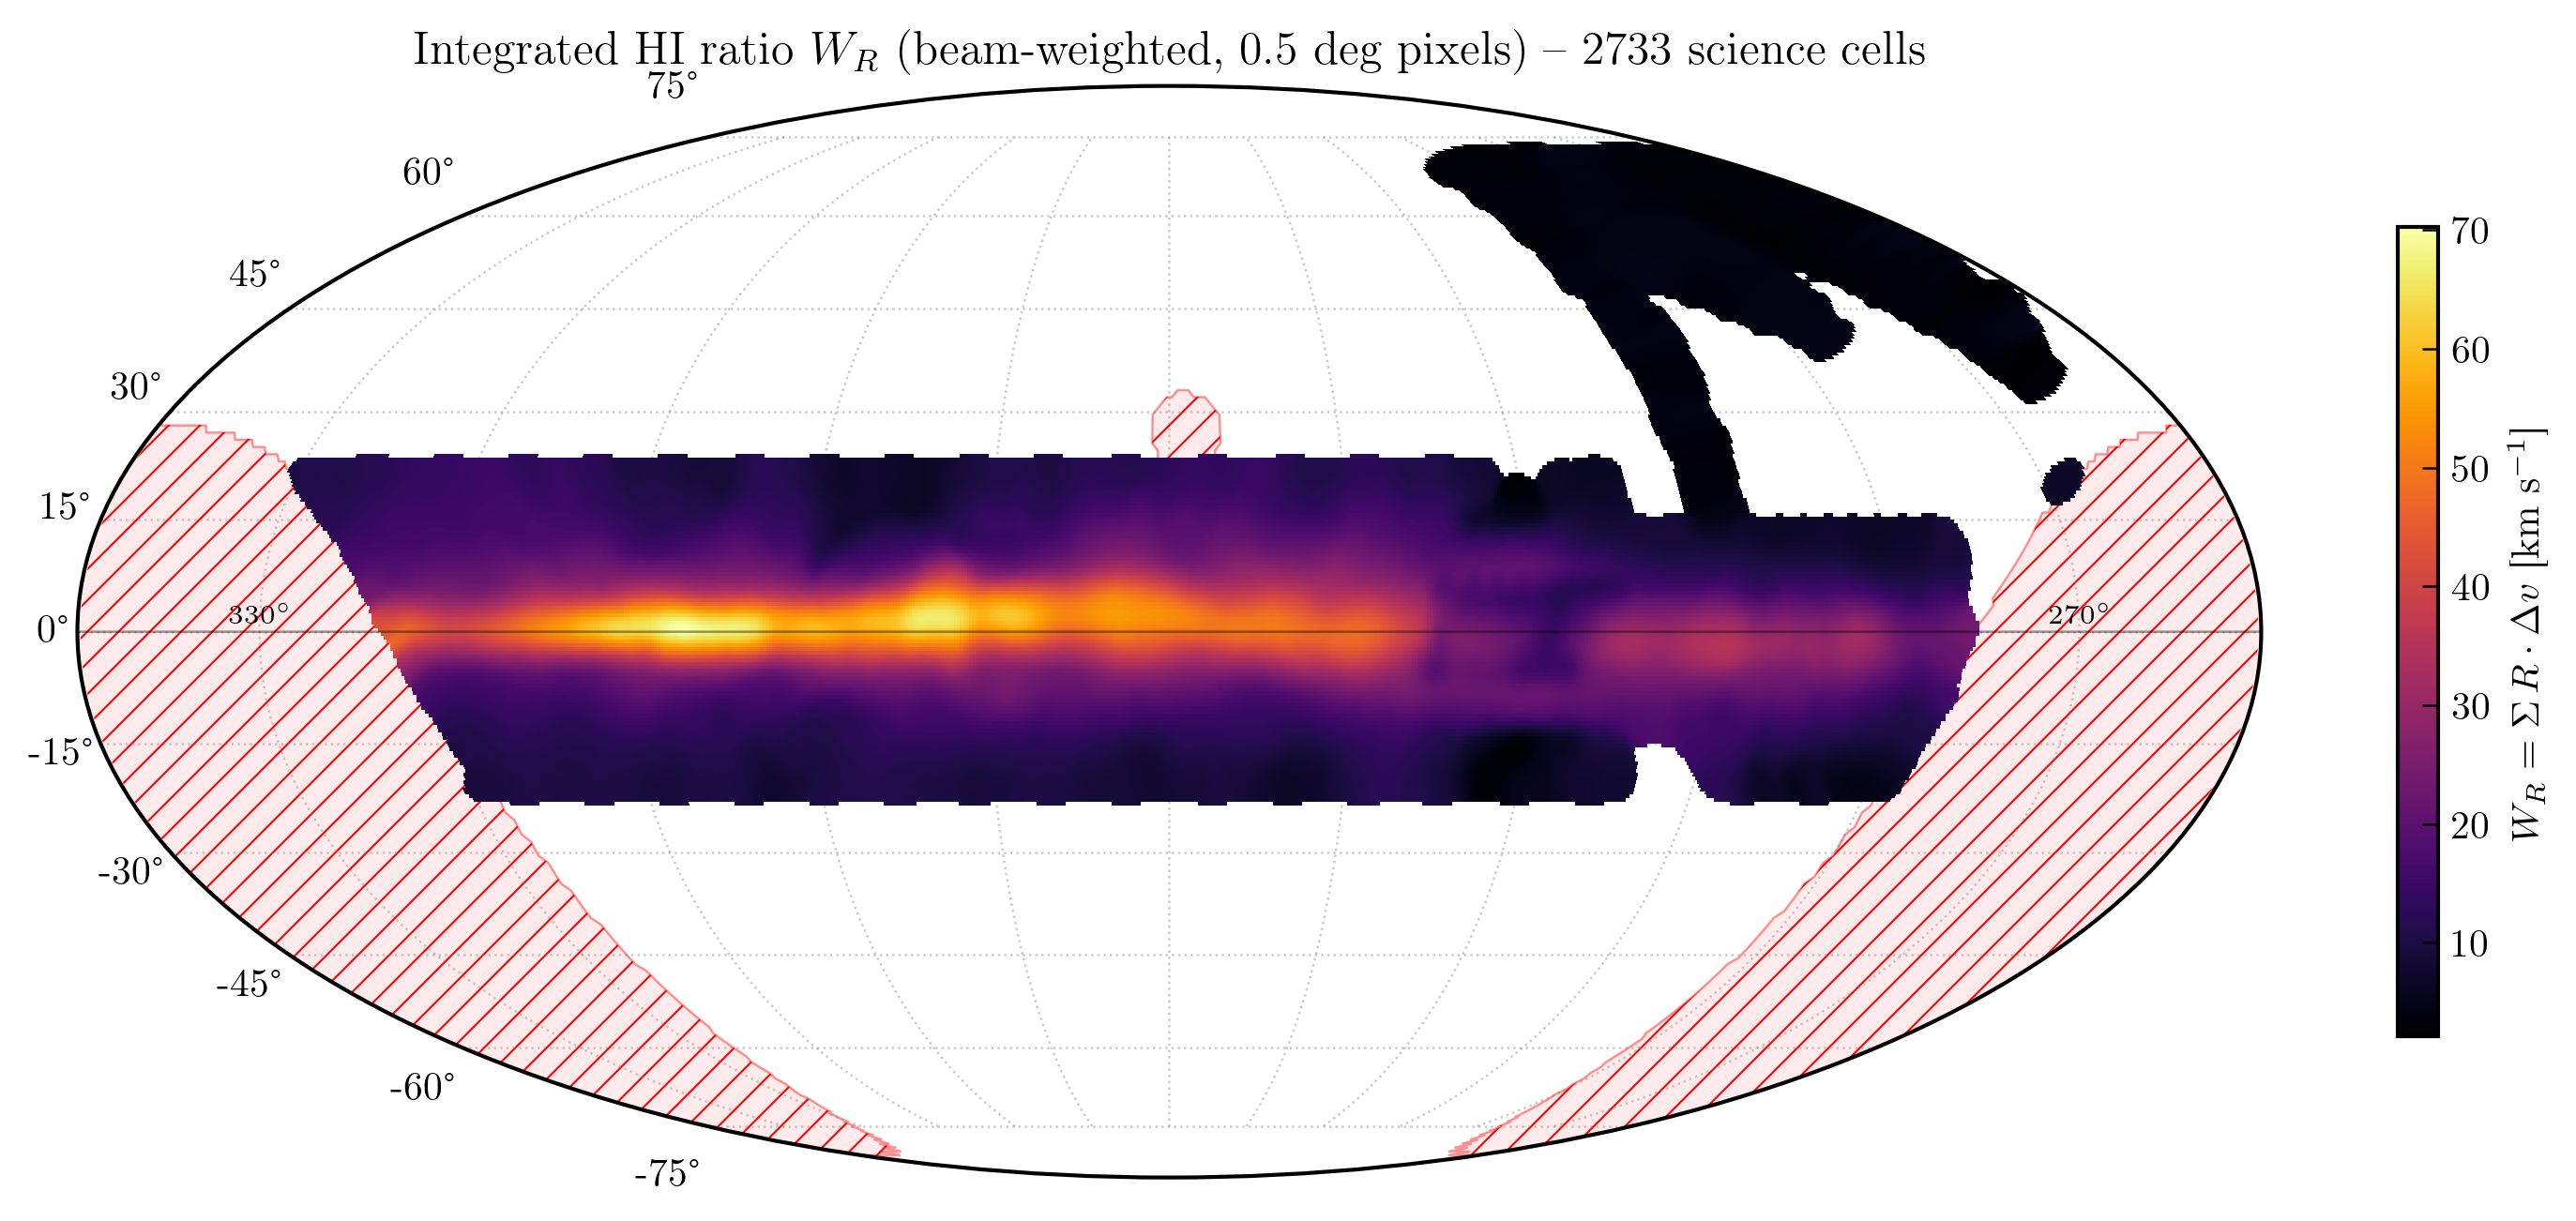

In [7]:
PIXEL_DEG = 0.5      # Mollweide pixel size (deg); finer than HPBW for smooth fill
CUTOFF_HPBW = 2.0    # include pointings within this many HPBW of each pixel center

fig, ax = plot_survey_mollweide_gridded(
    gl_arr[valid_R], gb_arr[valid_R], W_R[valid_R],
    center_l=MOLL_CENTER_L,
    cbar_label=r'$W_R = \Sigma\, R \cdot \Delta v$ [km s$^{-1}$]',
    cmap='inferno',
    hpbw_deg=HPBW_DEG,
    pixel_deg=PIXEL_DEG,
    cutoff_hpbw=CUTOFF_HPBW,
    title=(f'Integrated HI ratio $W_R$ (beam-weighted, {PIXEL_DEG} deg pixels) -- '
           f'{arrs["n_sci"]} science cells'),
)
plt.show()

## 6b. Beam-weighted $\ell$-$v$ strip at $b \approx 0$

### Why an $\ell$-$v$ diagram

For sightlines through the Galactic plane the position-velocity image
$T_B(\ell, v_{\mathrm{LSR}})$ at fixed $b = 0$ is the standard
diagnostic for Galactic rotation and spiral structure (Lab manual
Sec. 7, "Project: The Galactic Plane"). Under the assumption of pure
circular rotation in a thin disk with rotation curve $V(R)$, an HI
parcel at Galactocentric radius $R$ along longitude $\ell$ exhibits
the LSR Doppler velocity (Burton 1988, Lab manual eq. (\ref{vdopp})):

$$ V_{\mathrm{LSR}}(\ell, R)\;=\;
   \left[\,\frac{V(R)}{R} - \frac{V(R_\odot)}{R_\odot}\,\right]\,
   R_\odot\,\sin\ell, $$

with $R_\odot = 8.5$ kpc, $V(R_\odot) \approx 220$ km s$^{-1}$. Each
sightline at $\ell$ thus traces a one-parameter locus in
$(R,\,V_{\mathrm{LSR}})$. Inside the solar circle
($0 < \sin\ell\le 1$ with $R < R_\odot$) the locus has a turning point
at the *tangent radius* $R_t = R_\odot\sin\ell$, which sets the
maximum observable LSR velocity along that sightline:

$$ V_{\mathrm{LSR}}^{\max}(\ell)\;=\;V(R_t) - V(R_\odot)\sin\ell. $$

Reading the upper envelope of the $\ell$-$v$ image off this equation
yields $V(R)$ directly for the inner Galaxy ("tangent-point method")
-- the most direct route to the inner-Galaxy rotation curve. Outside
the solar circle, $V(R) \approx 220$ km s$^{-1}$ is assumed roughly
constant and the same projection turns logarithmic spiral arms
$R_{\mathrm{arm}}(\phi) = R_0\,e^{\kappa(\phi - \phi_0)}$
(Lab manual eq. (1), pitch angle $\arctan\kappa$) into characteristic
curves in $(\ell, v)$. The resulting Galactic mass inside the solar
circle follows from $v^2 = G M_{\mathrm{grav}}/R$.

### Beam weighting on the great circle

To maximise the signal we use *all* cells with $|b|\le b_{\max}$, not
only $b = 0$, and project each onto a fine longitude grid using the
true great-circle distance to the strip:

$$ \cos\theta_{p}(\ell)\;=\;\cos b_p\,\cos(\ell - \ell_p)
   \quad\Longrightarrow\quad
   \theta_p(\ell)\;=\;\arccos\bigl(\cos b_p\,\cos(\ell - \ell_p)\bigr). $$

(This is the spherical law of cosines specialised to the great circle
$b = 0$.) Apply the Gaussian beam weight
$w_p(\ell) = \exp[-\tfrac12 (\theta_p/\sigma)^2]$ with
$\sigma = \theta_{\mathrm{HPBW}}/2.355$, hard-truncated at
`cutoff_hpbw` $\times$ HPBW. The strip pixel is then the weighted mean
of all contributing cells' spectra,

$$ I(\ell, v)\;=\;
   \frac{\sum_p w_p(\ell)\,R^{(p)}(v)}{\sum_p w_p(\ell)}, $$

evaluated channel-by-channel in $v$. Pixels whose total weight falls
below `min_weight`, or where no cell lies within
`keep_near_hpbw` $\times$ HPBW, are masked (NaN). The latter blanks
the never-observable wedge naturally, without explicit segment
bookkeeping.

The image is still in the dimensionless ratio $R(v_{\mathrm{LSR}})$;
the brightness-temperature calibration ($T_B = R\cdot T_{\mathrm{sys}}$)
is applied in `main_scan_qa.ipynb` so that the upper envelope can be
read off in physical units for the rotation-curve fit.

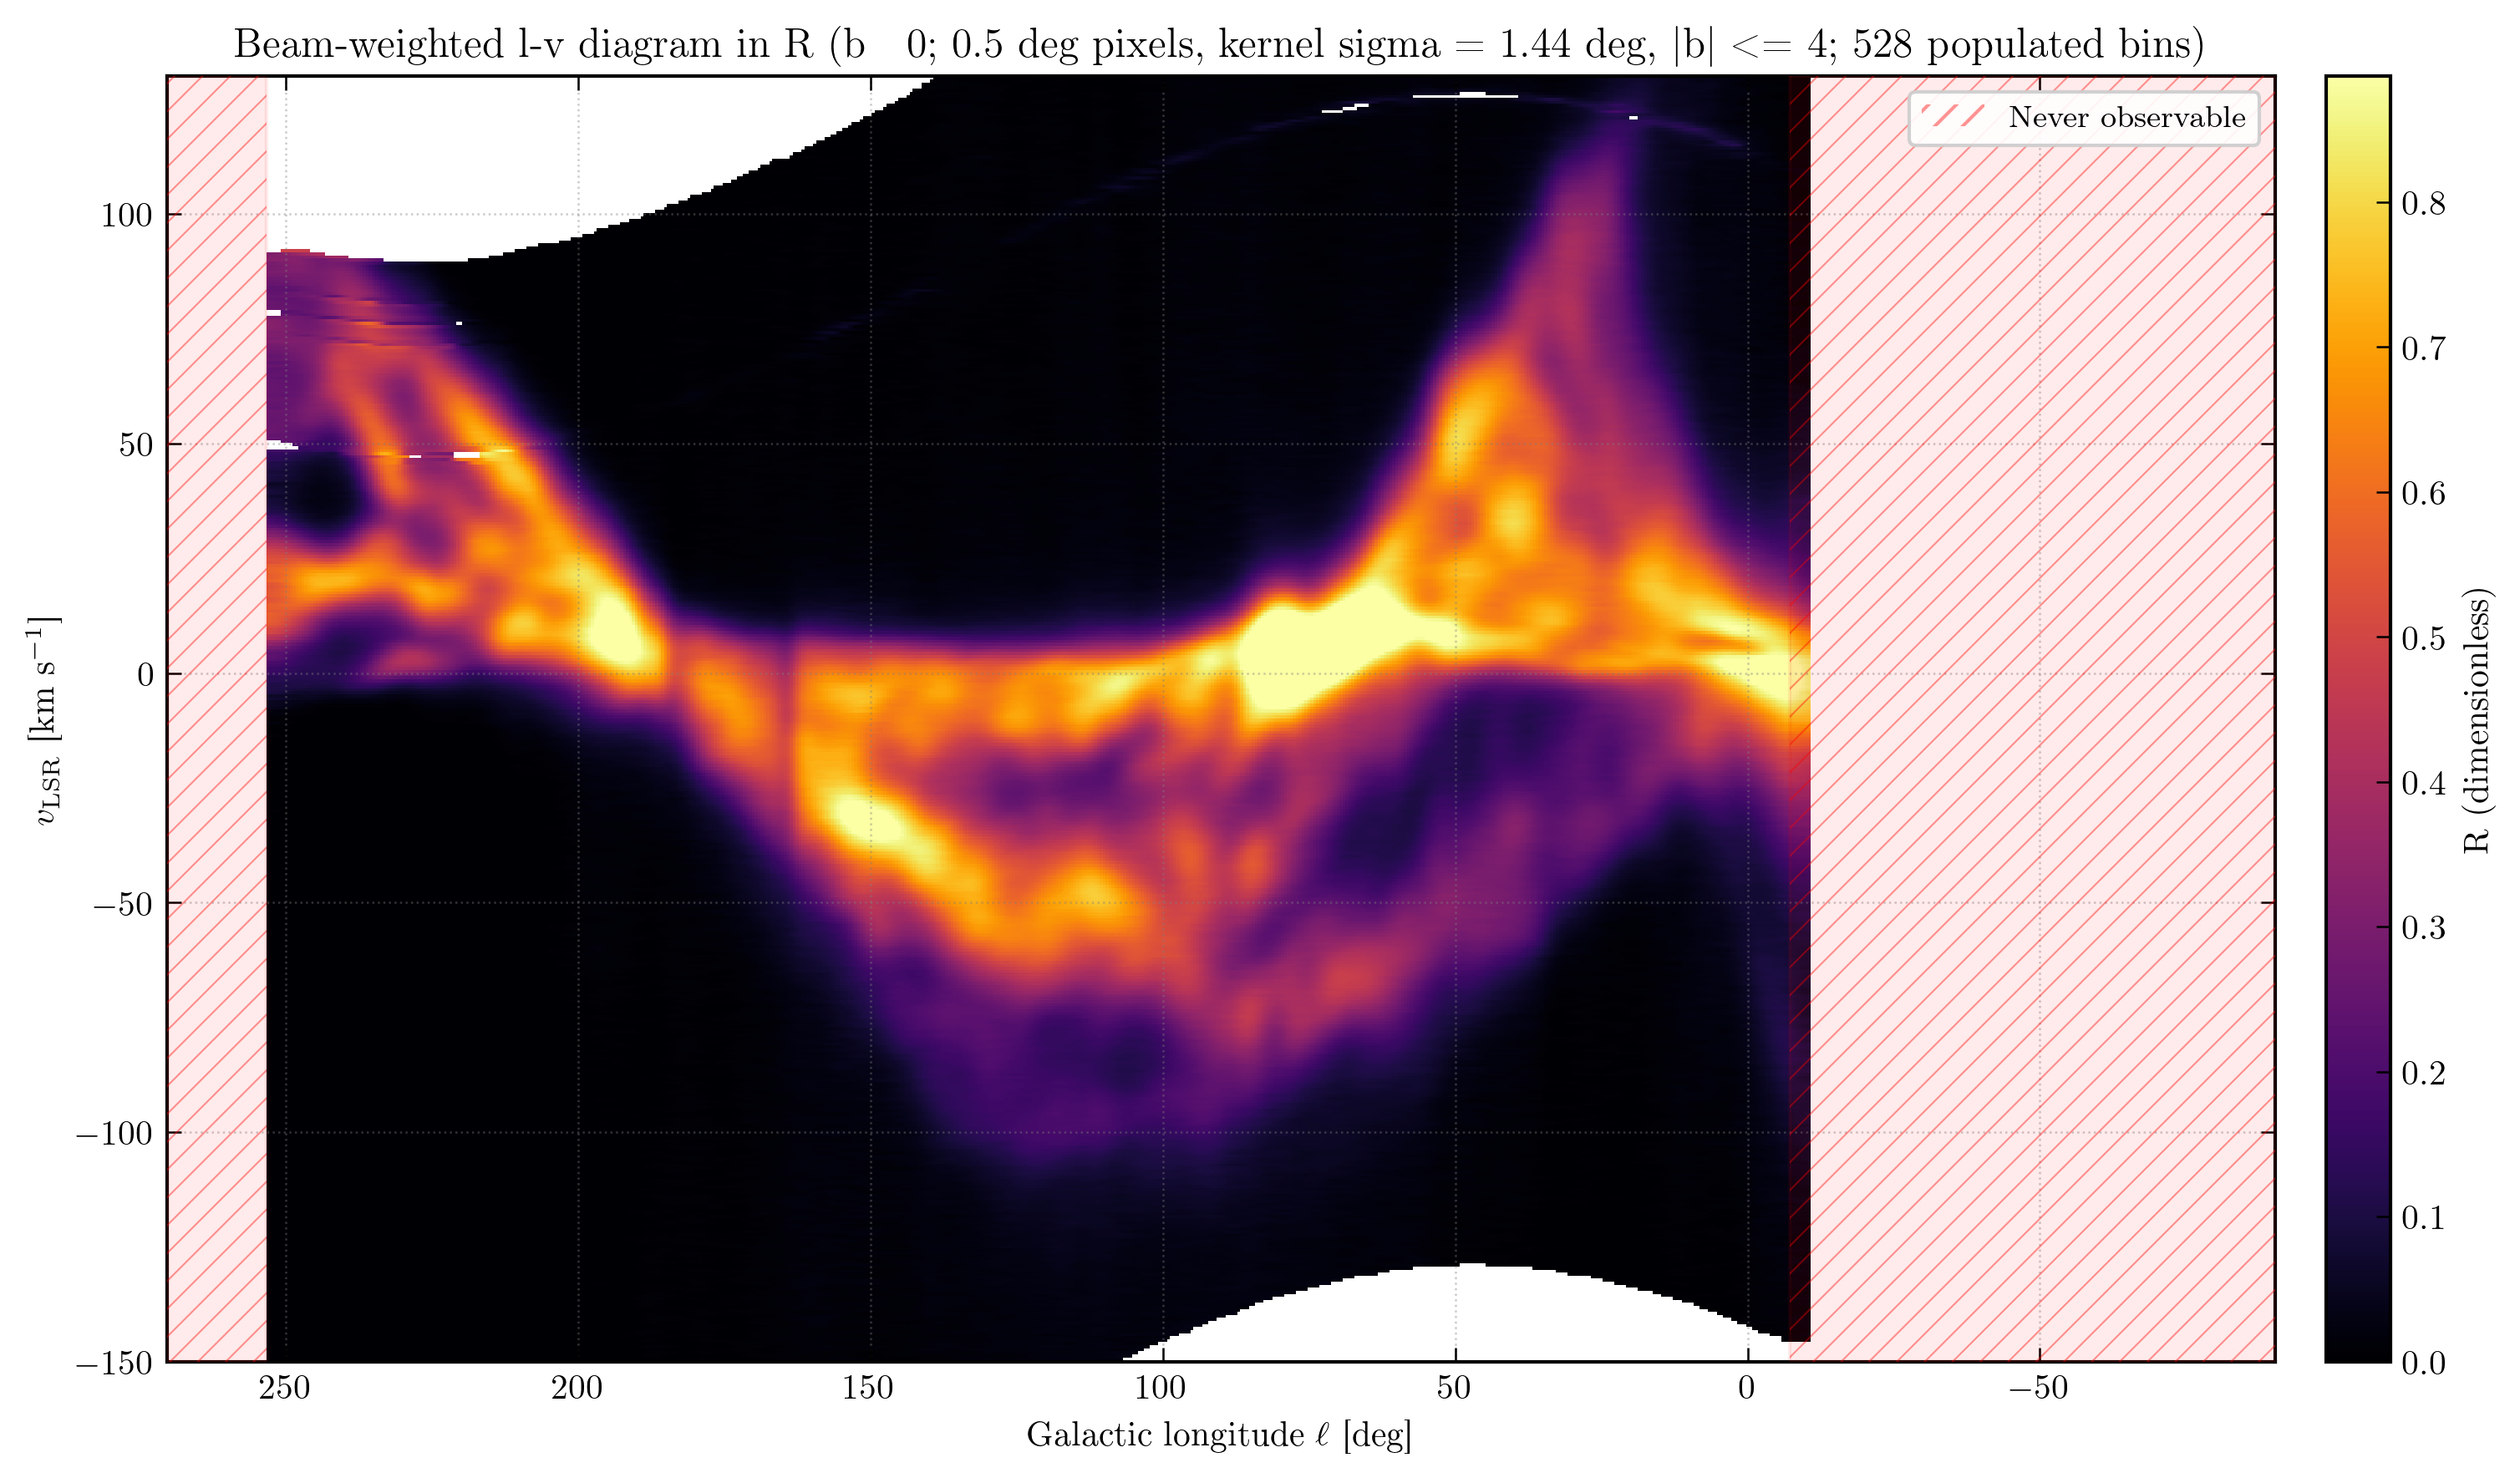

In [8]:
from utils import compute_lv_strip
from plotters import plot_lv_strip

LV_DL_FINE = 0.5
B_MAX_DEG = 4.0

strip = compute_lv_strip(
    cell_combined, cells_insufficient_pairs,
    b_max_deg=B_MAX_DEG,
    dl_fine_deg=LV_DL_FINE,
    hpbw_deg=HPBW_DEG,
    cutoff_hpbw=CUTOFF_HPBW,  # share Section 6's value (2.0)
    spectrum_key='R',
)

fig, ax = plot_lv_strip(
    strip['l_fine'], v_lsr_overlap, strip['lv_image'],
    title=(f"Beam-weighted l-v diagram in R (b ~ 0; "
           f"{LV_DL_FINE} deg pixels, kernel sigma = {strip['sigma_deg']:.2f} deg, "
           f"|b| <= {B_MAX_DEG:.0f}; {strip['n_populated']} populated bins)"),
    cbar_label='R (dimensionless)',
)
plt.show()

## 7. Per-cell calibration scalars (band-averaged $P_{\mathrm{on}}$, $P_{\mathrm{off}}$)

### The four power measurements

Per cell, per LO, per pol, the survey records two kinds of dump:
noise-diode off (`obs_*`) and noise-diode on (`cal_*`). Heiles's
receiver model (`cal_intensity.tex`, Sec. 3 eqs.
(\ref{ponline}-\ref{pcalon})) gives at channel $j$:

$$ \begin{aligned}
   P_j^{\mathrm{OFF}} &\;=\;G_j\,\bigl(T_{\mathrm{sys}}
       + T_{B}(\nu_j)\bigr),\\
   P_j^{\mathrm{ON}}  &\;=\;G_j\,\bigl(T_{\mathrm{sys}} + T_{\mathrm{cal}}
       + T_{B}(\nu_j)\bigr).
   \end{aligned} $$

Subtracting cancels everything except the known noise-diode injection:

$$ P_j^{\mathrm{ON}} - P_j^{\mathrm{OFF}}\;=\;G_j\,T_{\mathrm{cal}}. $$

### Naive vs cool calibration

The **naive method** estimates $G_j$ per channel and uses it to recover
$T_B$ (`cal_intensity.tex` Sec. 3.1 eq. (\ref{naive3})):

$$ T_{\mathrm{sys}} + T_B(\nu_j)\;=\;
   \frac{P_j^{\mathrm{OFF}}}{P_j^{\mathrm{ON}} - P_j^{\mathrm{OFF}}}\,
   T_{\mathrm{cal}}\quad\text{(naive)}. $$

This is honest but channel-noisy: the denominator is a *difference* of
two noisy spectra and its fractional noise propagates into every
channel of $T_B$ separately.

The **cool method** (eqs. (\ref{cool2})-(\ref{cool4})) exploits the
fact that $T_{\mathrm{sys}}$ is essentially frequency-independent over
our 1.4 MHz overlap. Sum the noisy $G_j T_{\mathrm{cal}}$ across the
full integration mask before dividing:

$$ T_{\mathrm{sys}}\;=\;
   \frac{\sum_j P_j^{\mathrm{OFF}}}
        {\sum_j\bigl(P_j^{\mathrm{ON}} - P_j^{\mathrm{OFF}}\bigr)}\,
   T_{\mathrm{cal}}
   \;=\;\frac{\langle P^{\mathrm{OFF}}\rangle}
              {\langle P^{\mathrm{ON}} - P^{\mathrm{OFF}}\rangle}\,
        T_{\mathrm{cal}}, $$

a single scalar. Its fractional noise improves by a factor
$\sqrt{N_{\mathrm{chan}}}$ over the per-channel naive estimate -- in
our case $\sqrt{N_{\mathrm{chan,overlap}}}\approx\sqrt{447}\approx 21$,
the number of channels in the LO overlap after the DC bin and
edge-trim are excluded -- because $T_{\mathrm{sys}}$ collapses to one
number rather than $\sim 450$ independent ones. Crucially, in our
pipeline the bandpass shape $G_j$ is already removed by frequency
switching (Section 3), so the *only* role of the diode is to set this
absolute scale $T_{\mathrm{sys}}$. We never have to perform the naive
per-channel division.

### Why we cache scalars now and apply $T_{\mathrm{cal}}(t)$ later

The diode temperature itself drifts on multi-day scales as the
electronics warm up and ambient temperature varies. The two recal
pointings near the celestial pole (Dec $= +72^\circ$, $\ell\in
\{90, 180\}$, observed every 10 cells) are at fixed $T_B$ targets, so
inverting the cool-method equation on those visits gives a per-pol,
per-visit estimate of $T_{\mathrm{cal}}^{\mathrm{pol}}(t)$. This is
solved in `main_scan_calibration.ipynb` and stored as a smooth trace
that QA interpolates onto each science-cell time.

For each `(session, gl, gb)`, each LO in $(\nu_1, \nu_2)$, and each
pol, this cell band-averages $P_{\mathrm{on}}$ and $P_{\mathrm{off}}$
over `INT_MASK` (the LO overlap, *minus* the DC bin at channel 512)
into two scalars apiece. The entire per-cell, per-pol scalar table is
tiny (${\sim} 2800\times 8$ floats) but sufficient to apply calibration
without re-touching the raw dumps:

$$ T_{\mathrm{sys}}^{\mathrm{pol}}(t)
   \;=\;T_{\mathrm{cal}}^{\mathrm{pol}}(t)\,
   \frac{\langle P_{\mathrm{off}}^{\mathrm{pol}}\rangle}
        {\langle P_{\mathrm{on}}^{\mathrm{pol}}
              - P_{\mathrm{off}}^{\mathrm{pol}}\rangle},
   \qquad
   T_B^{\mathrm{pol}}(v)\;=\;R^{\mathrm{pol}}(v)\,
       T_{\mathrm{sys}}^{\mathrm{pol}}(t). $$

Per-pol propagation is mandatory because the noise diode is slightly
polarised: $T_{\mathrm{cal}}^{(0)} = 58$ K vs
$T_{\mathrm{cal}}^{(1)} = 79$ K (Lab manual Sec. 4.3). The two
pol-calibrated brightnesses are summed at plot time to form Stokes I.

### A note on cal:obs scheduling

Heiles's "equal-time" optimum (`cal_intensity.tex` Sec. 4.2) says that
under a fixed total integration budget the noise on $T_{\mathrm{sys}}$
is minimised when equal time is spent on `CALON` and `CALOFF`. Our
schedule (`cal_dumps_per_lo = 2`, `obs_dumps_per_lo = 4`: $1{:}2$
cal-to-obs) deliberately deviates from this because the science
quantity is $T_B = R\cdot T_{\mathrm{sys}}$, not $T_{\mathrm{sys}}$
itself. The cool method already drives the fractional noise on
$T_{\mathrm{sys}}$ to ${\sim}1\%$ even with the short cal time, so
shifting more time to obs reduces the fractional noise on $R$ (and
therefore on $T_B$) directly. The break-even point depends on the
relative weight given to the multiplicative ($\delta T_{\mathrm{sys}} /
T_{\mathrm{sys}}$) and additive ($\delta R \cdot T_{\mathrm{sys}}$)
error terms; for HI-survey work the additive term dominates and the
$1{:}2$ split is close to optimal.

In [9]:
from utils import compute_cell_scalars

INT_MASK = overlap_mask.copy()
INT_MASK[NFFT // 2] = False  # exclude DC bin

cell_scalars = compute_cell_scalars(
    records, int_mask=INT_MASK, lo_freqs=(F1_MHZ, F2_MHZ),
)
n_full = sum(
    1 for e in cell_scalars.values()
    if all(
        np.isfinite(e[f'P_on_{pol}_{lo:g}']) and np.isfinite(e[f'P_off_{pol}_{lo:g}'])
        for lo in (F1_MHZ, F2_MHZ)
        for pol in ('pol0', 'pol1')
    )
)
print(f'Per-(session, cell) calibration scalars: {len(cell_scalars)} entries')
print(f'  {n_full} have on/off for both LOs and both pols (fully calibratable)')


Per-(session, cell) calibration scalars: 2790 entries
  2790 have on/off for both LOs and both pols (fully calibratable)


In [10]:
# Export state for main_scan_qa.ipynb /
# main_scan_load_diagnostics.ipynb.  cell_combined entries carry the
# per-pol dimensionless ratios R_pol0(v_LSR) and R_pol1(v_LSR); plot
# stages sum them.  cell_scalars carries per-pol band-averaged P_on /
# P_off scalars (P_on_pol{0,1}_{lo}, P_off_pol{0,1}_{lo}) so QA can
# apply Tcal_pol(t) to each pol independently:
#   T_sys_pol = Tcal_pol(t) * P_off_pol / (P_on_pol - P_off_pol)
#   T_B_pol   = R_pol * T_sys_pol
import pickle

state = {
    'cell_combined': cell_combined,
    'viable_pairs_per_cell': viable_pairs_per_cell,
    'cells_insufficient_pairs': cells_insufficient_pairs,
    'v_lsr_overlap': v_lsr_overlap,
    'dv_kms': dv_kms,
    'overlap_mask': overlap_mask,
    'int_mask': INT_MASK,
    'sessions': sessions,
    'lo_pair_mhz': (F1_MHZ, F2_MHZ),
    'cell_scalars': cell_scalars,
}
with open(STATE_PATH, 'wb') as f:
    pickle.dump(state, f)
print(f'Wrote {STATE_PATH} ({STATE_PATH.stat().st_size/1e6:.2f} MB) -- '
      f'{len(cell_combined)} science cells, '
      f'{len(cell_scalars)} cell-scalar entries')


Wrote artifacts/scan_load_state.pkl (112.69 MB) -- 2733 science cells, 2790 cell-scalar entries
